<a href="https://colab.research.google.com/github/StepanTita/nano-BERT/blob/main/imdb_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! rm -rf nano-BERT
! git clone https://github.com/StepanTita/nano-BERT.git

Cloning into 'nano-BERT'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 47 (delta 20), reused 30 (delta 8), pack-reused 0
Receiving objects: 100% (47/47), 38.31 MiB | 20.08 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Updating files: 100% (11/11), done.


In [2]:
import sys

sys.path.append('/content/nano-BERT')

In [1]:
import math
import json
from collections import Counter

import torch
import torch.nn.functional as F

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

from tqdm import tqdm

import matplotlib.pyplot as plt
import plotly.graph_objects as go

from nano_bert.model import NanoBertForClassification
from nano_bert.tokenizer import WordTokenizer

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
data = None
with open('data/imdb_train.json') as f:
    data = [json.loads(l) for l in f.readlines()]

In [5]:
vocab = set()
for d in data:
    vocab |= set([w.lower() for w in d['text']])

In [6]:
test_data = None
with open('data/imdb_test.json') as f:
   test_data = [json.loads(l) for l in f.readlines()]

In [7]:
def encode_label(label):
    if label == 'pos':
        return 1
    elif label == 'neg':
        return 0
    raise Exception(f'Unknown Label: {label}!')


class IMDBDataloader:
    def __init__(self, data, test_data, tokenizer, label_encoder, batch_size, val_frac=0.2):
        train_data, val_data = train_test_split(data, shuffle=True, random_state=42, test_size=val_frac)

        self.splits = {
            'train': [d['text'] for d in train_data],
            'test': [d['text'] for d in test_data],
            'val': [d['text'] for d in val_data]
        }

        self.labels = {
            'train': [d['label'] for d in train_data],
            'test': [d['label'] for d in test_data],
            'val': [d['label'] for d in val_data]
        }

        self.tokenized = {
            'train': [tokenizer(record).unsqueeze(0) for record in
                      tqdm(self.splits['train'], desc='Train Tokenization')],
            'test': [tokenizer(record).unsqueeze(0) for record in tqdm(self.splits['test'], desc='Test Tokenization')],
            'val': [tokenizer(record).unsqueeze(0) for record in tqdm(self.splits['val'], desc='Val Tokenization')],
        }

        self.encoded_labels = {
            'train': [label_encoder(label) for label in tqdm(self.labels['train'], desc='Train Label Encoding')],
            'test': [label_encoder(label) for label in tqdm(self.labels['test'], desc='Test Label Encoding')],
            'val': [label_encoder(label) for label in tqdm(self.labels['val'], desc='Val Label Encoding')],
        }

        self.curr_batch = 0
        self.batch_size = batch_size
        self.iterate_split = None

    def peek(self, split):
        return {
            'input_ids': self.splits[split][self.batch_size * self.curr_batch:self.batch_size * (self.curr_batch + 1)],
            'label_ids': self.labels[split][self.batch_size * self.curr_batch:self.batch_size * (self.curr_batch + 1)],
        }

    def take(self, split):
        batch = self.splits[split][self.batch_size * self.curr_batch:self.batch_size * (self.curr_batch + 1)]
        labels = self.labels[split][self.batch_size * self.curr_batch:self.batch_size * (self.curr_batch + 1)]
        self.curr_batch += 1
        return {
            'input_ids': batch,
            'label_ids': labels,
        }

    def peek_tokenized(self, split):
        return {
            'input_ids': torch.cat(
                self.tokenized[split][self.batch_size * self.curr_batch:self.batch_size * (self.curr_batch + 1)],
                dim=0),
            'label_ids': torch.tensor(
                self.encoded_labels[split][self.batch_size * self.curr_batch:self.batch_size * (self.curr_batch + 1)],
                dtype=torch.long),
        }

    def peek_index_tokenized(self, index, split):
        return {
            'input_ids': torch.cat(
                [self.tokenized[split][index]],
                dim=0),
            'label_ids': torch.tensor(
                [self.encoded_labels[split][index]],
                dtype=torch.long),
        }

    def peek_index(self, index, split):
        return {
            'input_ids': [self.splits[split][index]],
            'label_ids': [self.labels[split][index]],
        }

    def take_tokenized(self, split):
        batch = self.tokenized[split][self.batch_size * self.curr_batch:self.batch_size * (self.curr_batch + 1)]
        labels = self.encoded_labels[split][self.batch_size * self.curr_batch:self.batch_size * (self.curr_batch + 1)]
        self.curr_batch += 1
        return {
            'input_ids': torch.cat(batch, dim=0),
            'label_ids': torch.tensor(labels, dtype=torch.long),
        }

    def get_split(self, split):
        self.iterate_split = split
        return self

    def steps(self, split):
        return len(self.tokenized[split]) // self.batch_size

    def __iter__(self):
        self.reset()
        return self

    def __next__(self):
        if self.batch_size * self.curr_batch < len(self.splits[self.iterate_split]):
            return self.take_tokenized(self.iterate_split)
        else:
            raise StopIteration

    def reset(self):
        self.curr_batch = 0

In [8]:
NUM_EPOCHS = 200
BATCH_SIZE = 32
MAX_SEQ_LEN = 128
LEARNING_RATE = 1e-4

In [9]:
tokenizer = WordTokenizer(vocab=vocab, max_seq_len=MAX_SEQ_LEN)
tokenizer

Tokenizer[vocab=101522,self.special_tokens=['[PAD]', '[CLS]', '[SEP]', '[UNK]'],self.sep=' ',self.max_seq_len=128]

In [10]:
dataloader = IMDBDataloader(data, test_data, tokenizer, encode_label, batch_size=BATCH_SIZE)

Val Label Encoding: 100%|██████████| 5000/5000 [00:00<00:00, 6749765.05it/s]


In [12]:
bert = NanoBertForClassification(
    vocab_size=len(tokenizer.vocab),
    n_layers=1,
    n_heads=1,
    max_seq_len=MAX_SEQ_LEN,
    n_classes=2
).to(device)
from hiq.vis import print_model
print_model(bert)

🌳 NanoBertForClassification<all params:305123>
├── NanoBERT(nano_bert)
│   ├── BertEmbeddings(embedding)
│   │   ├── Embedding(word_embeddings)|weight[101522,3]
│   │   ├── Embedding(pos_embeddings)|weight[128,3]
│   │   └── LayerNorm(layer_norm)|weight[3]|bias[3]
│   ├── BertEncoder(encoder)
│   │   └── ModuleList(layers)
│   │       └── BertLayer(0)
│   │           ├── 💠 ]8;id=865392;/home/wukong/miniconda3/envs/genaibook/lib/python3.10/site-packages/torch/nn/modules/normalization.py\LayerNorm]8;;\]8;id=375475;/home/wukong/miniconda3/envs/genaibook/lib/python3.10/site-packages/torch/nn/modules/normalization.py\(layer_norm1,layer_norm2)<🦜:6x2>|]8;;\]8;id=142234;/home/wukong/miniconda3/envs/genaibook/lib/python3.10/site-packages/torch/nn/modules/normalization.py\weight[3]|]8;;\]8;id=26571;/home/wukong/miniconda3/envs/genaibook/lib/python3.10/site-packages/torch/nn/modules/normalization.py\bias[3]]8;;\
│   │           ├── BertSelfAttention(self_attention)
│   │           │   ├── ModuleList(heads)
│   │           │   │   └── BertAttentionHead(0)
│   │           │   │       └── 💠 ]8;id=952761;/home/wukong/miniconda3/envs/genaibook/lib/python3.10/site-packages/torch/nn/modules/linear.py\Linear]8;;\]8;id=744481;/home/wukong/miniconda3/envs/genaibook/lib/python3.10/site-packages/torch/nn/modules/linear.py\(query,key,values)<🦜:12x3>|]8;;\]8;id=736662;/home/wukong/miniconda3/envs/genaibook/lib/python3.10/site-packages/torch/nn/modules/linear.py\weight[3,3]|]8;;\]8;id=130486;/home/wukong/miniconda3/envs/genaibook/lib/python3.10/site-packages/torch/nn/modules/linear.py\bias[3]]8;;\
│   │           │   └── Linear(proj)|weight[3,3]|bias[3]
│   │           └── FeedForward(feed_forward)
│   │               └── Sequential(ffwd)
│   │                   ├── Linear(0)|weight[12,3]|bias[12]
│   │                   └── Linear(2)|weight[3,12]|bias[3]
│   └── BertPooler(pooler)
│       └── Linear(dense)|weight[3,3]|bias[3]
└── Linear(classifier)|weight[2,3]|bias[2]

In [13]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [14]:
count_parameters(bert)

305123

In [15]:
history = {
    'train_losses': [],
    'val_losses': [],
    'train_acc': [],
    'val_acc': [],
    'train_f1': [],
    'val_f1': []
}

In [16]:
optimizer = torch.optim.Adam(bert.parameters(), lr=LEARNING_RATE)

for i in range(NUM_EPOCHS):
    print(f'Epoch: {i + 1}')
    train_loss = 0.0
    train_preds = []
    train_labels = []

    bert.train()
    for step, batch in enumerate(tqdm(dataloader.get_split('train'), total=dataloader.steps('train'))):
        logits = bert(batch['input_ids'].to(device)) # (B, Seq_Len, 2)

        probs = F.softmax(logits[:, 0, :], dim=-1).cpu()
        pred = torch.argmax(probs, dim=-1) # (B)
        train_preds += pred.detach().tolist()
        train_labels += [l.item() for l in batch['label_ids']]

        loss = F.cross_entropy(logits[:, 0, :].cpu(), batch['label_ids'])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    val_loss = 0.0
    val_preds = []
    val_labels = []

    bert.eval()
    for step, batch in enumerate(tqdm(dataloader.get_split('val'), total=dataloader.steps('val'))):
        logits = bert(batch['input_ids'].to(device))

        probs = F.softmax(logits[:, 0, :], dim=-1).cpu()
        pred = torch.argmax(probs, dim=-1) # (B)
        val_preds += pred.detach().tolist()
        val_labels += [l.item() for l in batch['label_ids']]

        loss = F.cross_entropy(logits[:, 0, :].cpu(), batch['label_ids'])

        val_loss += loss.item()

    history['train_losses'].append(train_loss)
    history['val_losses'].append(val_loss)
    history['train_acc'].append(accuracy_score(train_labels, train_preds))
    history['val_acc'].append(accuracy_score(val_labels, val_preds))
    history['train_f1'].append(f1_score(train_labels, train_preds))
    history['val_f1'].append(f1_score(val_labels, val_preds))

    print()
    print(f'Train loss: {train_loss / dataloader.steps("train")} | Val loss: {val_loss / dataloader.steps("val")}')
    print(f'Train acc: {accuracy_score(train_labels, train_preds)} | Val acc: {accuracy_score(val_labels, val_preds)}')
    print(f'Train f1: {f1_score(train_labels, train_preds)} | Val f1: {f1_score(val_labels, val_preds)}')

Epoch: 1


100%|██████████| 625/625 [00:02<00:00, 276.92it/s]
157it [00:00, 1684.99it/s]             



Train loss: 0.6954350086212158 | Val loss: 0.6989802465989039
Train acc: 0.50075 | Val acc: 0.497
Train f1: 0.0 | Val f1: 0.0
Epoch: 2


100%|██████████| 625/625 [00:01<00:00, 425.50it/s]
157it [00:00, 1669.92it/s]             



Train loss: 0.6936023002624512 | Val loss: 0.6979419417106189
Train acc: 0.50075 | Val acc: 0.497
Train f1: 0.0 | Val f1: 0.0
Epoch: 3


...


Train loss: 0.3761234870433807 | Val loss: 0.5456359802912443
Train acc: 0.84145 | Val acc: 0.748
Train f1: 0.8416004795444327 | Val f1: 0.7608200455580866
Epoch: 199


100%|██████████| 625/625 [00:01<00:00, 459.47it/s]
157it [00:00, 1926.89it/s]             



Train loss: 0.376625896024704 | Val loss: 0.5466966378765229
Train acc: 0.8368 | Val acc: 0.746
Train f1: 0.8366039247096516 | Val f1: 0.7609186746987951
Epoch: 200


100%|██████████| 625/625 [00:01<00:00, 458.93it/s]
157it [00:00, 1824.03it/s]             



Train loss: 0.37759444510936735 | Val loss: 0.5490382768404789
Train acc: 0.83825 | Val acc: 0.7438
Train f1: 0.8388061188898301 | Val f1: 0.7604264073312137


In [17]:
def plot_results(history, do_val=True):
    fig, ax = plt.subplots(figsize=(8, 8))

    x = list(range(0, len(history['train_losses'])))

    # loss

    ax.plot(x, history['train_losses'], label='train_loss')

    if do_val:
        ax.plot(x, history['val_losses'], label='val_loss')

    plt.title('Train / Validation Loss')
    plt.legend(loc='upper right')

    # accuracy

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.plot(x, history['train_acc'], label='train_acc')

    if do_val:
        ax.plot(x, history['val_acc'], label='val_acc')

    plt.title('Train / Validation Accuracy')
    plt.legend(loc='upper right')

    # f1-score

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.plot(x, history['train_f1'], label='train_f1')

    if do_val:
        ax.plot(x, history['val_f1'], label='val_f1')

    plt.title('Train / Validation F1')
    plt.legend(loc='upper right')

    fig.show()

/tmp/ipykernel_38804/1763888503.py:40: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


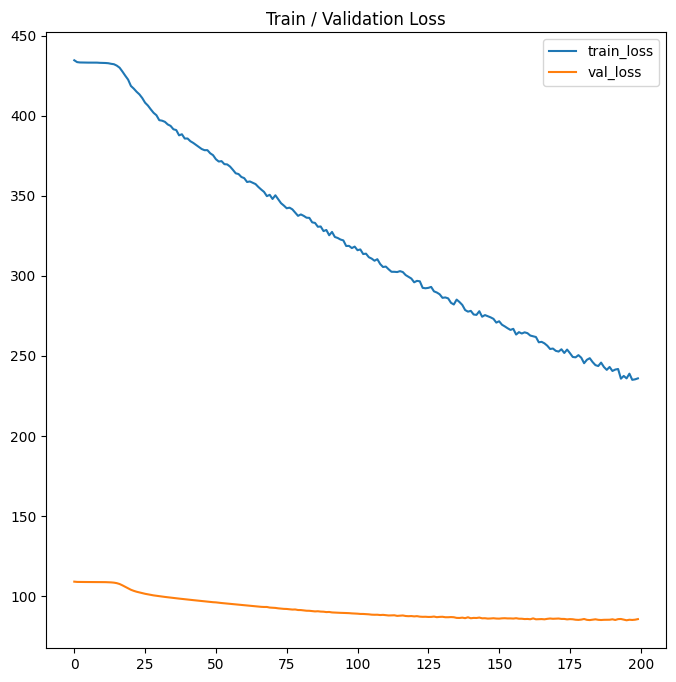

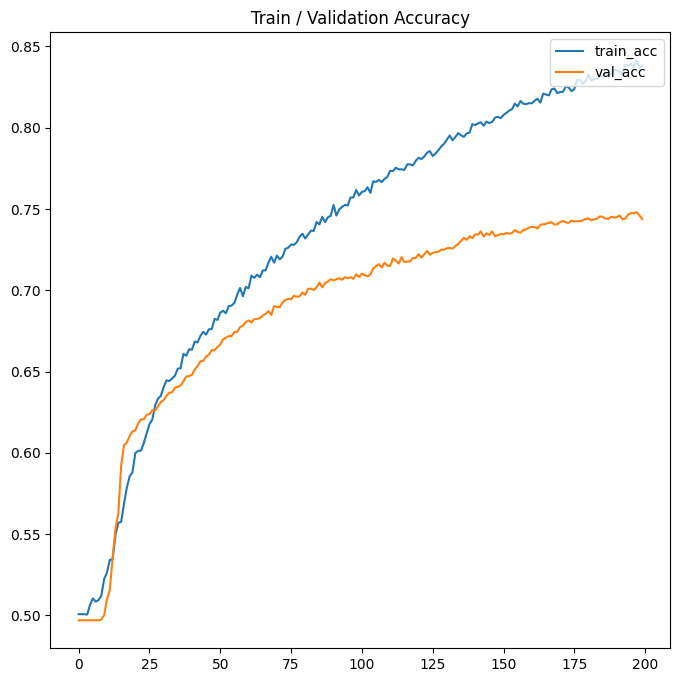

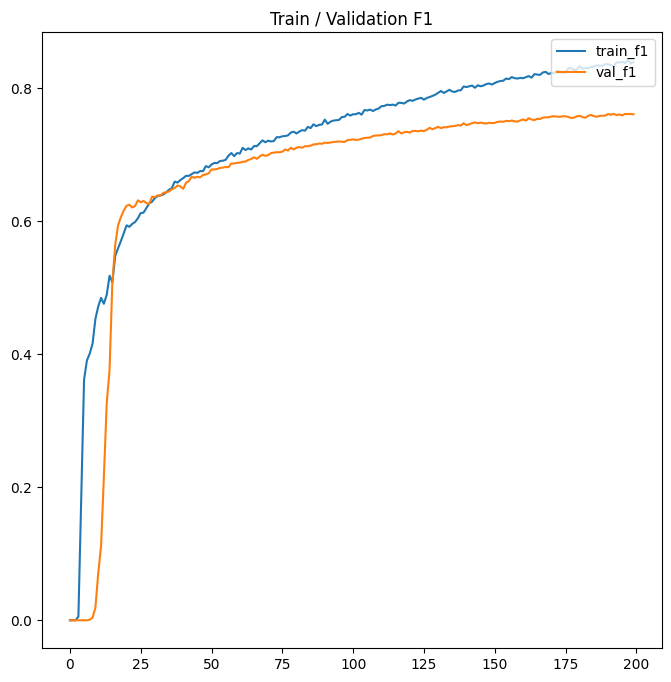

In [18]:
plot_results(history)

In [19]:
test_loss = 0.0
test_preds = []
test_labels = []

bert.eval()
for step, batch in enumerate(tqdm(dataloader.get_split('test'), total=dataloader.steps('test'))):
    logits = bert(batch['input_ids'].to(device))

    probs = F.softmax(logits[:, 0, :], dim=-1).cpu()
    pred = torch.argmax(probs, dim=-1) # (B)
    test_preds += pred.detach().tolist()
    test_labels += [l.item() for l in batch['label_ids']]

    loss = F.cross_entropy(logits[:, 0, :].cpu(), batch['label_ids'])

    test_loss += loss.item()

print()
print(f'Test loss: {test_loss / dataloader.steps("test")}')
print(f'Test acc: {accuracy_score(test_labels, test_preds)}')
print(f'Test f1: {f1_score(test_labels, test_preds)}')

782it [00:00, 1862.38it/s]                         


Test loss: 0.5742699384460376
Test acc: 0.72868
Test f1: 0.7456978967495219


# Interpreting and visualizing the results

In [20]:
def get_attention_scores(model, input_ids):
    """
    This is just a wrapper to easily access attention heads of the last layer
    """

    mask = (input_ids > 0).unsqueeze(1).repeat(1, input_ids.size(1), 1)

    embed = model.nano_bert.embedding(input_ids)

    # can be any layer, and we can also control what to do with output for each layer (aggregate, sum etc.)
    layer = model.nano_bert.encoder.layers[-1]

    x = layer.layer_norm1(embed)

    B, seq_len, n_embed = x.shape

    # if have more than 1 head, or interested in more than 1 head output just add aggregation here
    head = layer.self_attention.heads[0]

    # this is just a part of the single head that does all the computations (same code is present in AttentionHead)
    q = head.query(x)
    k = head.key(x)
    v = head.values(x)

    weights = (q @ k.transpose(-2, -1)) / math.sqrt(n_embed)  # (B, Seq_len, Seq_len)
    weights = weights.masked_fill(mask == 0, -1e9)  # mask out not attended tokens

    scores = F.softmax(weights, dim=-1)

    return scores

In [21]:
test_dataloader = IMDBDataloader(data, test_data, tokenizer, encode_label, batch_size=1)

Val Label Encoding: 100%|██████████| 5000/5000 [00:00<00:00, 6223002.97it/s]


In [22]:
def plot_parallel(matrix, tokens):
    # Set figsize
    plt.figure(figsize=(12, 8))

    input_len = len(tokens)

    # Vertical lines
    plt.axvline(x=1, color='black', linestyle='--', linewidth=1)
    plt.axvline(x=5, color='black', linestyle='--', linewidth=1)

    # Add the A and B
    plt.text(1, input_len + 1, 'A', fontsize=12, color='black', fontweight='bold')
    plt.text(5, input_len + 1, 'B', fontsize=12, color='black', fontweight='bold')

    for i in range(input_len):
        for j in range(input_len):
            # Add the line to the plot
            plt.plot([1, 5], [i, j], marker='o', label='token', color='blue', linewidth=5 * matrix[i][j])

            plt.text(
                1 - 0.18,  # x-axis position
                i,  # y-axis position
                tokens[i],  # Text
                fontsize=8,  # Text size
                color='black',  # Text color,
            )

            plt.text(
                5 + 0.06,  # x-axis position
                j,  # y-axis position
                tokens[j],  # Text
                fontsize=8,  # Text size
                color='black',  # Text color
            )
        break

    plt.title(f'Attention scores \n\n\n')

    plt.yticks([])  # Remove y-axis
    plt.box(False)  # Remove the bounding box around plot
    plt.show()  # Display the chart

In [23]:
# examples with less than 16 words are easier to visualize, so focus on them
examples_ids = []
for i, v in enumerate(test_dataloader.splits['test']):
    if len(v) <= 16:
        examples_ids.append(i)
print(examples_ids)

[1959, 2939, 6394, 15789, 16349, 21487, 22019, 24588]


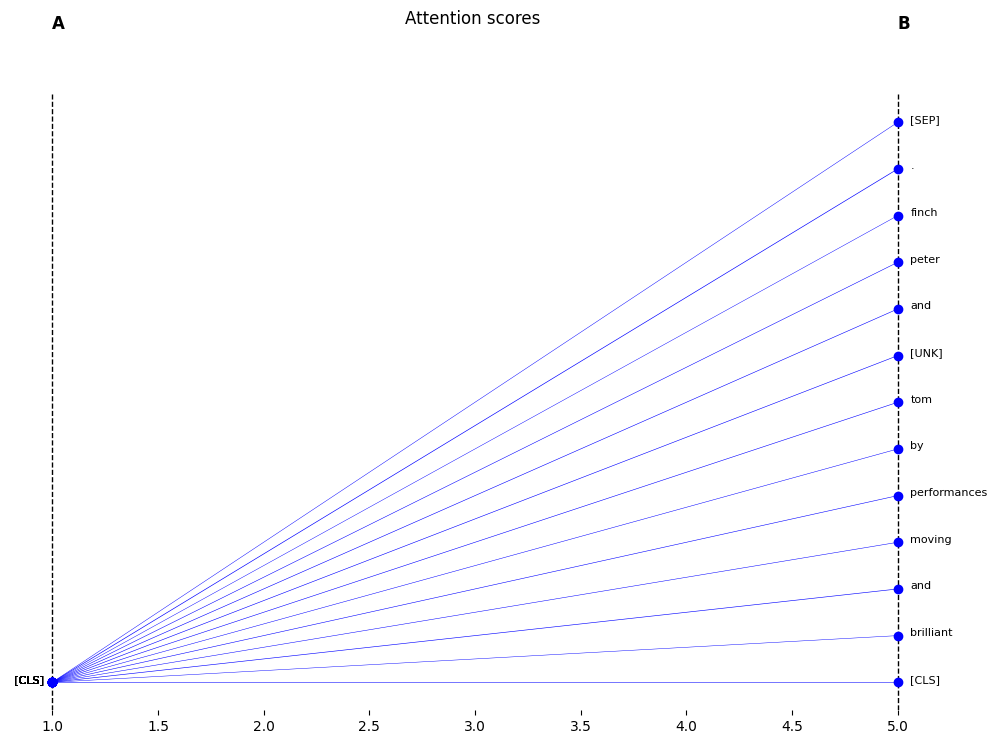

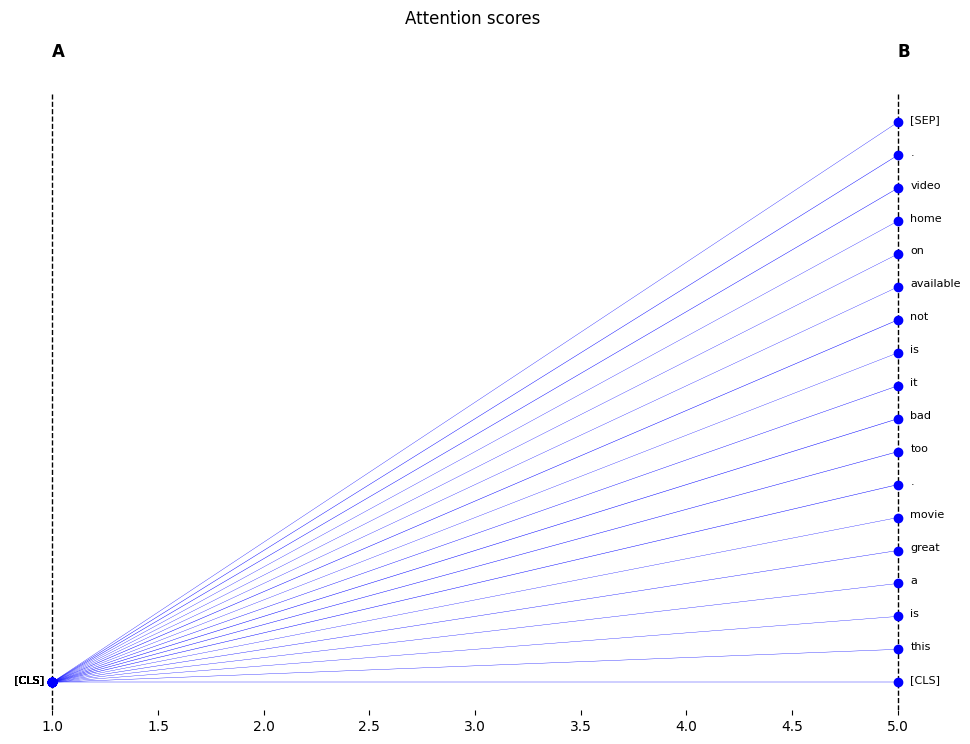

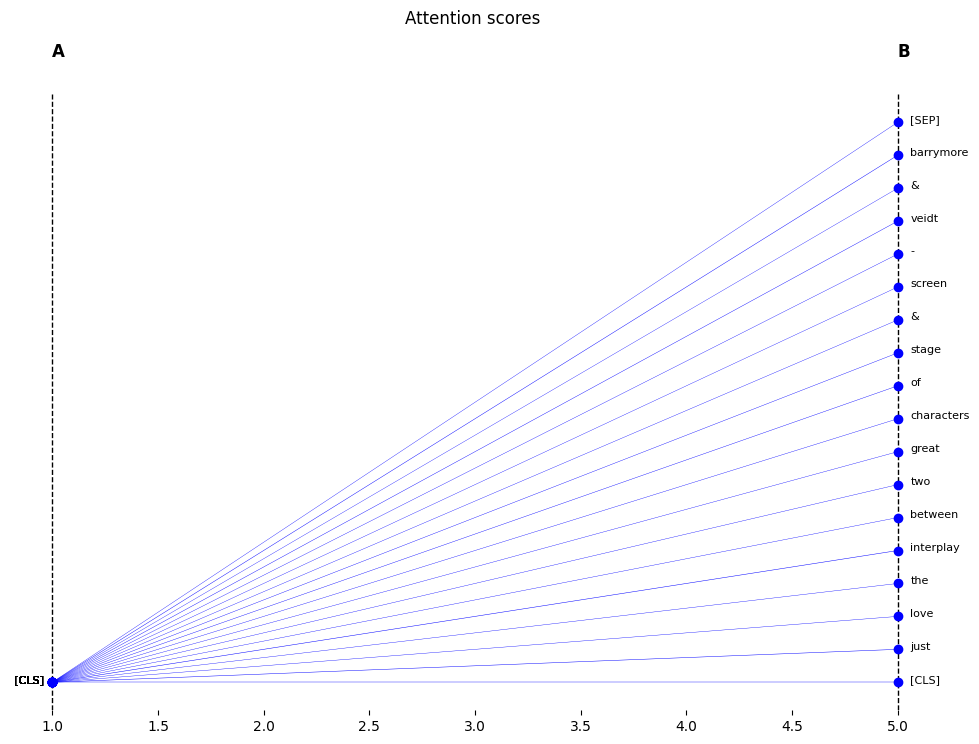

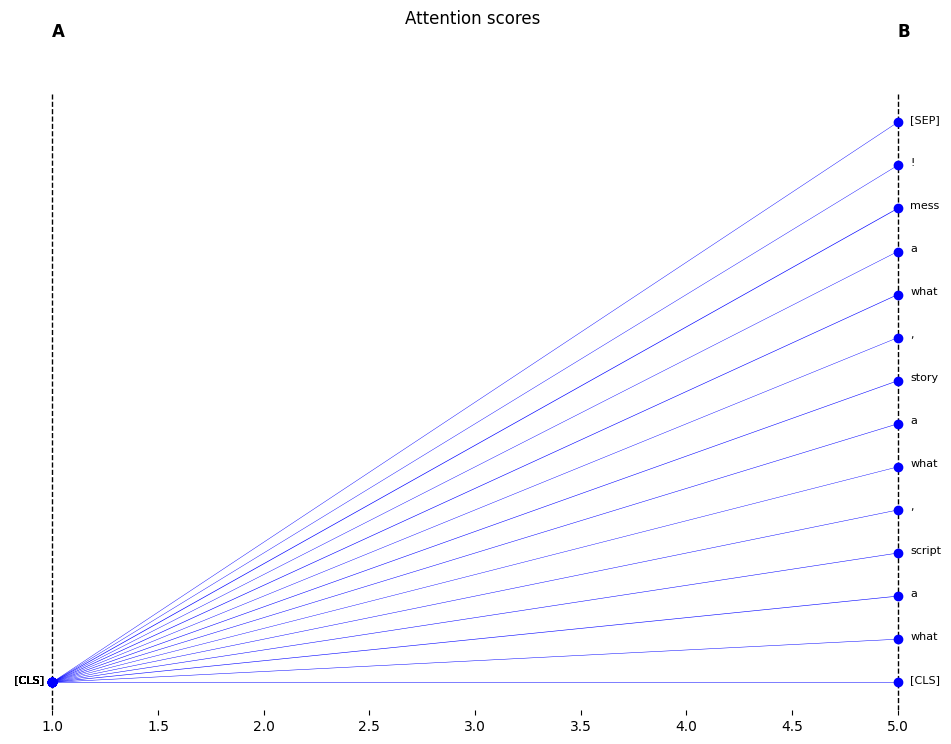

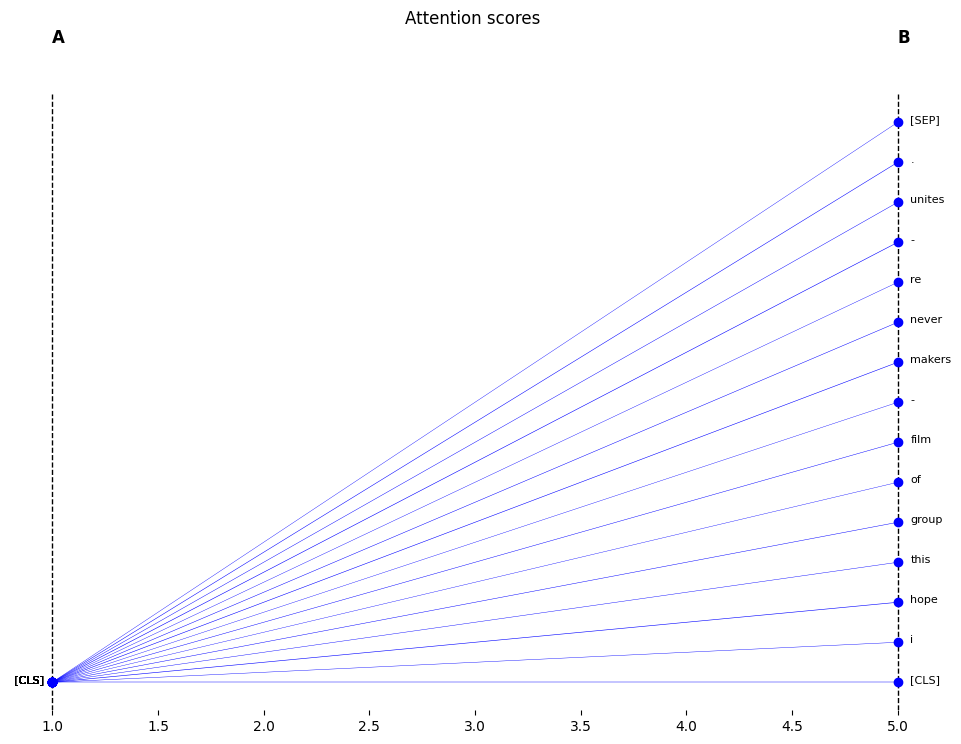

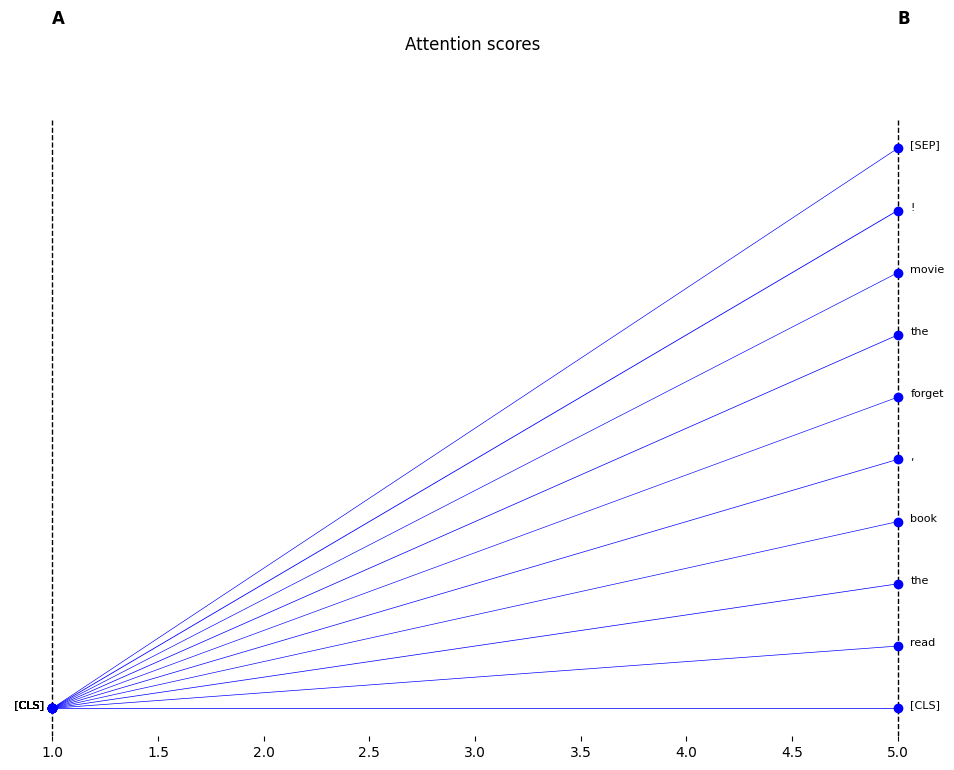

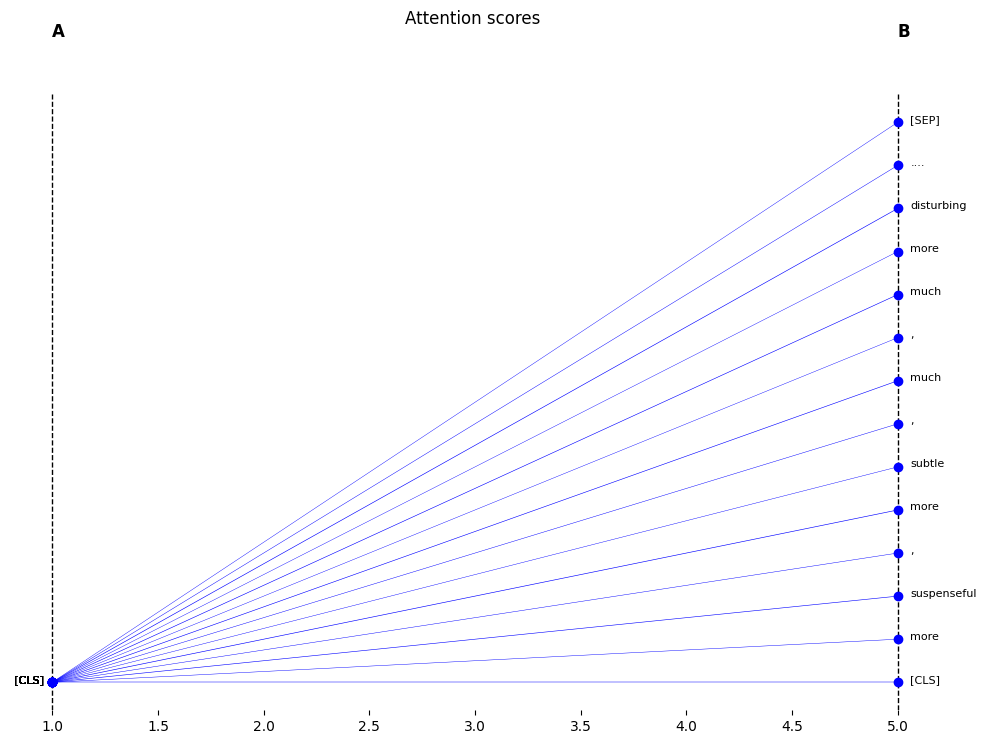

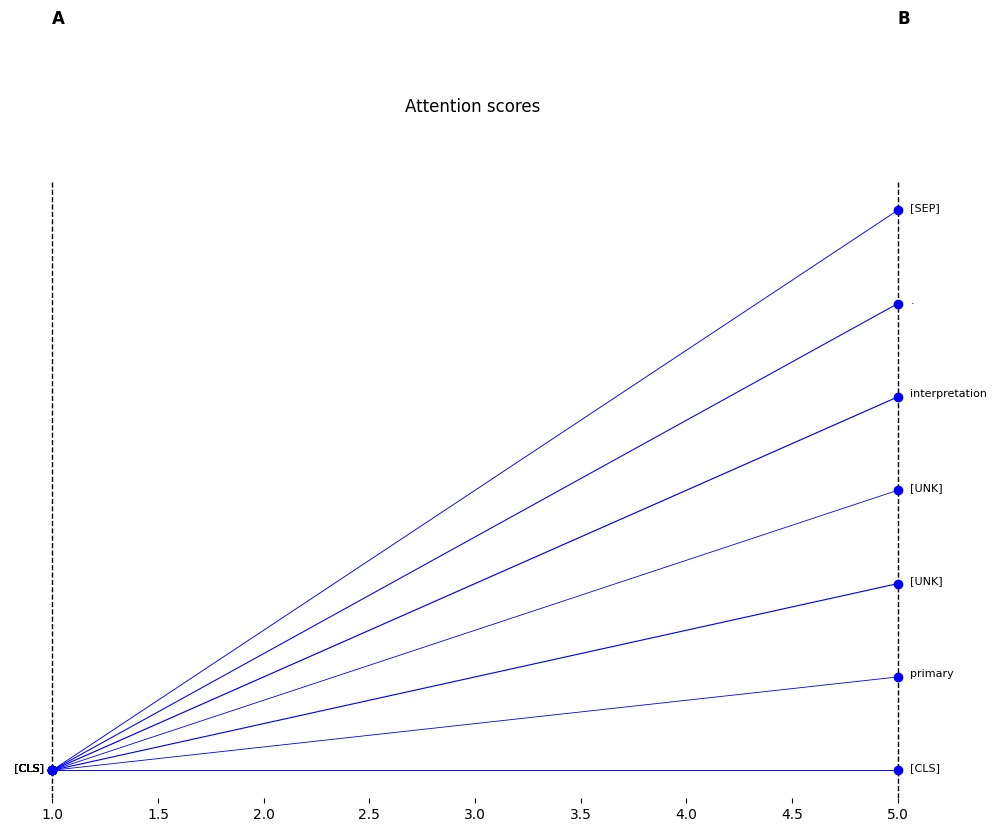

In [24]:
for sample_index in examples_ids:
    # extract example, decode to tokens and get the sequence length (ingoring padding)
    test_tokenized_batch = test_dataloader.peek_index_tokenized(index=sample_index, split='test')
    tokens = tokenizer.decode([t.item() for t in test_tokenized_batch['input_ids'][0] if t != 0], ignore_special=False).split(' ')[:MAX_SEQ_LEN]
    seq_len = len(tokens)

    # calculate attention scores
    att_matrix = get_attention_scores(bert, test_tokenized_batch['input_ids'].to(device))[0, :seq_len, :seq_len]

    plot_parallel(att_matrix, tokens=tokens)

In [25]:
scatters = []
for sample_index in examples_ids:
    # extract example, decode to tokens and get the sequence length (ingoring padding)
    test_tokenized_batch = test_dataloader.peek_index_tokenized(index=sample_index, split='test')
    tokens = tokenizer.decode([t.item() for t in test_tokenized_batch['input_ids'][0] if t != 0], ignore_special=False).split(' ')[:MAX_SEQ_LEN]
    seq_len = len(tokens)

    embed = bert.nano_bert.embedding(test_tokenized_batch['input_ids'].to(device))

    x, y, z = embed[0, :seq_len, 0].detach().cpu().numpy(), embed[0, :seq_len, 1].detach().cpu().numpy(), embed[0, :seq_len, 2].detach().cpu().numpy()

    scatters.append(go.Scatter3d(
        x=x, y=y, z=z, mode='markers+text', name=f'Example: {sample_index}',
        text=tokens,
    ))

In [26]:
fig = go.Figure(
    data=scatters,
    layout=go.Layout(
        title=go.layout.Title(text='Embeddings')
    ))
fig.show()

In [27]:
scatters = []
for sample_index in examples_ids:
    # extract example, decode to tokens and get the sequence length (ingoring padding)
    test_tokenized_batch = test_dataloader.peek_index_tokenized(index=sample_index, split='test')
    tokens = tokenizer.decode([t.item() for t in test_tokenized_batch['input_ids'][0] if t != 0], ignore_special=False).split(' ')[:MAX_SEQ_LEN]
    seq_len = len(tokens)

    embed = bert.nano_bert(test_tokenized_batch['input_ids'].to(device))

    x, y, z = embed[0, :seq_len, 0].detach().cpu().numpy(), embed[0, :seq_len, 1].detach().cpu().numpy(), embed[0, :seq_len, 2].detach().cpu().numpy()

    scatters.append(go.Scatter3d(
        x=x, y=y, z=z, mode='markers+text', name=f'Example: {sample_index}',
        text=tokens,
    ))

In [28]:
fig = go.Figure(
    data=scatters,
    layout=go.Layout(
        title=go.layout.Title(text='Raw Embeddings')
    ))
fig.show()